# Phase One: EDA and Dimensionality Reduction

In [1]:
import ee


print("Authenticating with Google Earth Engine...")
ee.Authenticate()

print("Initializing project...")
ee.Initialize(project="agriculture-drought-assesment")

Authenticating with Google Earth Engine...
Initializing project...


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

In [3]:
from IPython.display import Image, display

import importlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn import linear_model

from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from data import indices, load_CHIRPS, load_ERA5, load_S2, utils
from visualisation import index_plotter
from features import engineering

from pygam import LinearGAM, s

importlib.reload(indices)
importlib.reload(load_S2)
importlib.reload(load_ERA5)
importlib.reload(load_CHIRPS)
importlib.reload(utils)
importlib.reload(index_plotter)
importlib.reload(engineering)

<module 'features.engineering' from '/home/luke/projects/agriculture-analysis/src/features/engineering.py'>

# Prepare DataFrames

In [4]:
region = utils.get_region()
i_date = "2021-01-01"
f_date = "2024-12-31"

In [5]:
non_spectral_df = pd.read_csv("../data/raw/non_spectral_df.csv", index_col=0)
non_spectral_df["Timestamp"] = pd.to_datetime(non_spectral_df["Timestamp"])
spectral_df = pd.read_csv("../data/raw/spectral_df.csv", index_col=0)
spectral_df["Timestamp"] = pd.to_datetime(spectral_df["Timestamp"])
grouped_spectral_df = pd.read_csv("../data/raw/grouped_spectral_df.csv", index_col=0)
grouped_spectral_df["Timestamp"] = pd.to_datetime(grouped_spectral_df["Timestamp"])

### Growing degree days

GDDs are a heuristic used to measure heat accumulation to predict plant development rates. If the crops aren't heavily stressed by other anomalous environmental factors, the development rate from emergence to maturity depends on daily temperature. The variant we will use is:

$$GDD=\text{max}\left\{\frac{T_\text{max}+T_\text{min}}{2}-T_\text{base}, 0\right\}$$

Corn typically has 800 to 2700 GDD to crop maturity, with a recommended baseline of 10 °C.

In [6]:
def gdd(row):
    t_base = 10
    
    t_max = row["temperature_2m_max"] - 273.15
    t_min = row["temperature_2m_min"] - 273.15

    gdd = (t_max + t_min) / 2 - t_base
    return max(gdd, 0)

In [7]:
non_spectral_df["GDD"] = non_spectral_df.apply(gdd, axis=1)
non_spectral_df["GDD"].head()

0    10.006207
1     7.404952
2     7.165753
3     8.108309
4    10.420760
Name: GDD, dtype: float64

In [9]:
master_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)
master_df.head()

,Timestamp,NDVI_mean,NDVI_std,NDWI_mean,NDWI_std,NDRE_mean,NDRE_std,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,...,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation,GDD
0,2018-01-07,0.454175,0.017789,0.154850,0.001513,0.301027,0.005391,0.277943,0.320916,0.297231,...,298.093380,296.435354,293.480139,291.139993,296.411982,288.101550,305.198672,3.187154e+07,0.000000,13.500111
1,2018-03-03,0.629801,0.031419,0.310717,0.025493,0.438958,0.033150,0.275499,0.294964,0.281848,...,296.319232,295.264591,293.797097,292.708587,293.174303,284.739623,300.874879,2.653625e+07,5.928807,9.657251
2,2018-06-01,0.330054,0.013942,0.073200,0.005519,0.220654,0.008582,0.387392,0.309780,0.338261,...,283.614288,284.567219,286.777798,290.473939,281.743066,275.021431,288.422674,1.504906e+07,0.000000,0.000000
3,2018-06-06,0.289118,0.015937,-0.017437,0.002453,0.180388,0.010207,0.336953,0.310565,0.336209,...,281.924616,282.769941,285.820755,290.178382,280.752142,274.098569,288.798194,1.452415e+07,0.000000,0.000000
4,2018-06-11,0.264834,0.027659,-0.018403,0.011886,0.172670,0.016877,0.307676,0.305746,0.333914,...,282.930785,283.265651,285.249282,289.847651,281.838309,276.769477,289.060574,1.396338e+07,0.000000,0.000000


---

# Growth Stages

In the feature engineering chapters to follow, we will see that the relative growth stages of maize plays an integral role in defining the influence and interpretation of many of the environmental variables in our dataset. The challenge in an unsupervised learning problem like this is the fact that we don't have access to labels detailing the growth stages of the crop, so it takes some creativity to approximately classify where in the process our crop field is. 

Maize growth is divided into two main categories, **Vegetative (V)** and **Reproductive (R)**. The vegatative ranking is determined by the amount of visible collars on the plant. 

<img src="assets/maize_collars.jpg" width="350">

The plants grow up to a V18 or V21 stage, where-after it goes into a reproductive stage and loses its greenery. 

<img src="assets/V_n_R.jpg" width="500">



### Seasonal Cyclic GAM


Why is all this important? For the simple reason that one of our spectral indices, NDVI, is as such a measurement of the "greenery" of the maize crops. More concretely, a higher NDVI tells us that the vegatation in the area under consideration reflects more near-infrared and green light as compared to other wave-lengths, but absorbs more blue and red. The higher the NDVI, the healthier and more green is the crop. In other words, as greenery increases starting from planting season, the average NDVI graph will give us a good indication of the growth stages of the maize.


$$\text{NDVI}=\frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$$

In [11]:
plot_df = master_df[master_df["Timestamp"] < pd.to_datetime("2026-01-01")].copy()
plot_df = plot_df.sort_values("Timestamp")
plot_df["doy"] = plot_df["Timestamp"].dt.dayofyear

#jul1_doy = pd.Timestamp("2021-07-01").dayofyear
#plot_df["doy"] = ((plot_df["Timestamp"].dt.dayofyear - jul1_doy) % 365) + 1


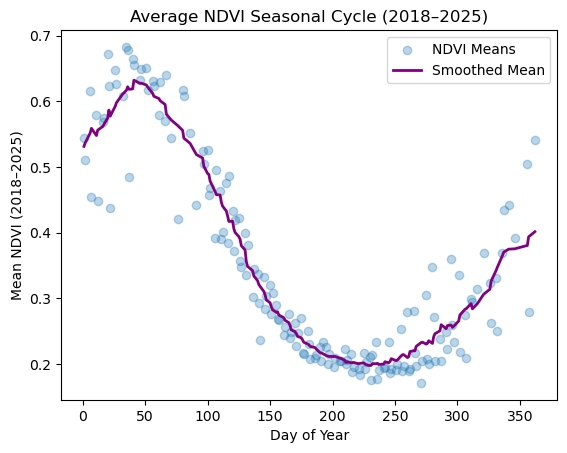

In [38]:

clim = plot_df.groupby("doy")["NDVI_mean"].mean().sort_index()
clim_smooth = clim.rolling(window=14, center=True, min_periods=1).mean()

plt.figure()
plt.scatter(clim.index, clim.values, alpha=0.3, label="NDVI Means")
plt.plot(clim_smooth.index, clim_smooth.values, linewidth=2, label="Smoothed Mean", color="purple")
plt.xlabel("Day of Year")
plt.ylabel("Mean NDVI (2018–2025)")
plt.title("Average NDVI Seasonal Cycle (2018–2025)")
plt.legend()
plt.show()

While the above graph certainly gives us a good picture of the **average** cycle of NDVI throughout the year, there are a few issues. First, this is purely the mean of means. There is a large discontinuity between the two end-points of the graph and therefore it is not cyclic. It is by no means a robust estimator of the NDVI cycle and therefore its residuals and derivatives should not be trusted for inference. Crucially, all these issues can mostly be solved by fitting a **Generalised Additive Model** (GAM) to our NDVI data. 

We first shift the DOY axis so that the growing season does not "carry over" to the following year. This will provide is with better behaviour from the cyclic spline. 

In [403]:
shift = pd.Timestamp("2019-08-01").dayofyear

def shift_doy(x):
    shifted_doy = ((x - shift) % 365) + 1
    return shifted_doy

def inv_shift_doy(x):
    inv_shifted_doy = (x + shift - 1) % 365
    return inv_shifted_doy

In [404]:
# Shift data to approximately before the start of the growing steason
shifted_doy = ((plot_df["Timestamp"].dt.dayofyear - shift) % 365) + 1
plot_df["shifted_doy"] = shifted_doy

doys = np.arange(1, 366)
agr_doys = ((doys - shift) % 365) + 1

# Define x-ticks for shifted axis
x_ticks = np.arange(1, 366, 30)
x_labels = ((x_ticks + shift - 1) % 365) + 1

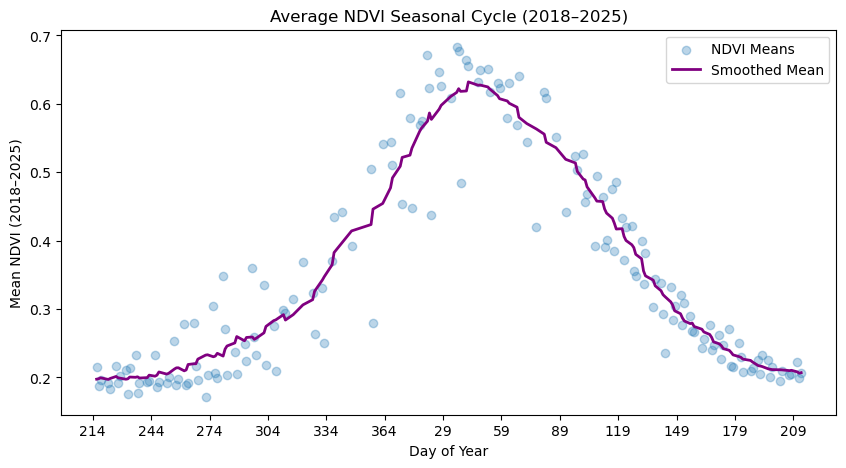

In [405]:

clim = plot_df.groupby("shifted_doy")["NDVI_mean"].mean().sort_index()
clim_smooth = clim.rolling(window=14, center=True, min_periods=1).mean()

plt.figure(figsize=(10, 5))
plt.scatter(clim.index, clim.values, alpha=0.3, label="NDVI Means")
plt.plot(clim_smooth.index, clim_smooth.values, linewidth=2, label="Smoothed Mean", color="purple")

plt.xticks(ticks = x_ticks, labels=x_labels)

plt.xlabel("Day of Year")
plt.ylabel("Mean NDVI (2018–2025)")
plt.title("Average NDVI Seasonal Cycle (2018–2025)")
plt.legend()
plt.show()

100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:000000


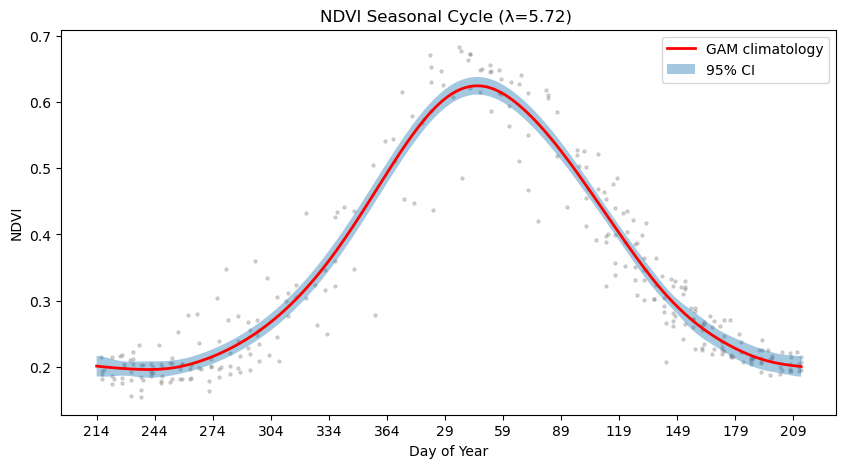

In [406]:
X = plot_df["shifted_doy"].values.reshape(-1, 1)
y = plot_df["NDVI_mean"].values

gam = LinearGAM(s(0, basis="cp"))

lam_grid = np.logspace(-5, 5, 100)
gam.gridsearch(X, y, lam=lam_grid)

X_pred = doys.reshape(-1, 1)
pred = gam.predict(X_pred)
ci = gam.confidence_intervals(X_pred, width=0.95)

plt.figure(figsize=(10, 5))
plt.title(f"NDVI Seasonal Cycle (λ={gam.terms[0].lam[0]:.2f}) ")

plt.scatter(x = plot_df["shifted_doy"], y=plot_df["NDVI_mean"], alpha=0.3, s=5, color='grey')
plt.plot(X_pred, pred, linewidth=2, color="red", label="GAM climatology")
plt.fill_between(X_pred.flatten(), ci[:, 0], ci[:, 1], alpha=0.4, label="95% CI")

plt.ylabel("NDVI")

plt.xticks(x_ticks, labels=x_labels)
plt.xlabel("Day of Year")

plt.legend()
plt.show()

This cyclic GAM is estimating $$NDVI_i = f(\text{DOY}_i)+\epsilon_i$$
i.e. estimating the average NDVI seasonal cycle as a function of the day of year (DOY). This gives us an interpolated seasonal curve, with the ability to find $f'(d)$ which will give us the average green-up rate of the crops.

In [407]:
dy_dx = np.gradient(pred, doys)
d2y_dx2 = np.gradient(dy_dx, doys)


growing_season = 0
peak_biomass = 0
max_senescence = inv_shift_doy(np.argmin(dy_dx))
max_green_up = inv_shift_doy(np.argmax(dy_dx))

for i in range(len(dy_dx) - 1):
    if dy_dx[i] * dy_dx[i+1] < 0:
        if dy_dx[i] < 0:
            growing_season = inv_shift_doy(doys[i])
            print(f"Zero crossing at DOY {growing_season} - Start of greening")
        else:
            peak_biomass = inv_shift_doy(doys[i])
            print(f"Zero crossing at DOY {peak_biomass} - Peak Biomass")

print(f"Minimum derivative at DOY {max_senescence} - Max Senescence (fastest browning)")
print(f"Maximum derivative at DOY {max_green_up} - Rate of growth reaches its maximum")

Zero crossing at DOY 239 - Start of greening
Zero crossing at DOY 44 - Peak Biomass
Minimum derivative at DOY 110 - Max Senescence (fastest browning)
Maximum derivative at DOY 357 - Rate of growth reaches its maximum


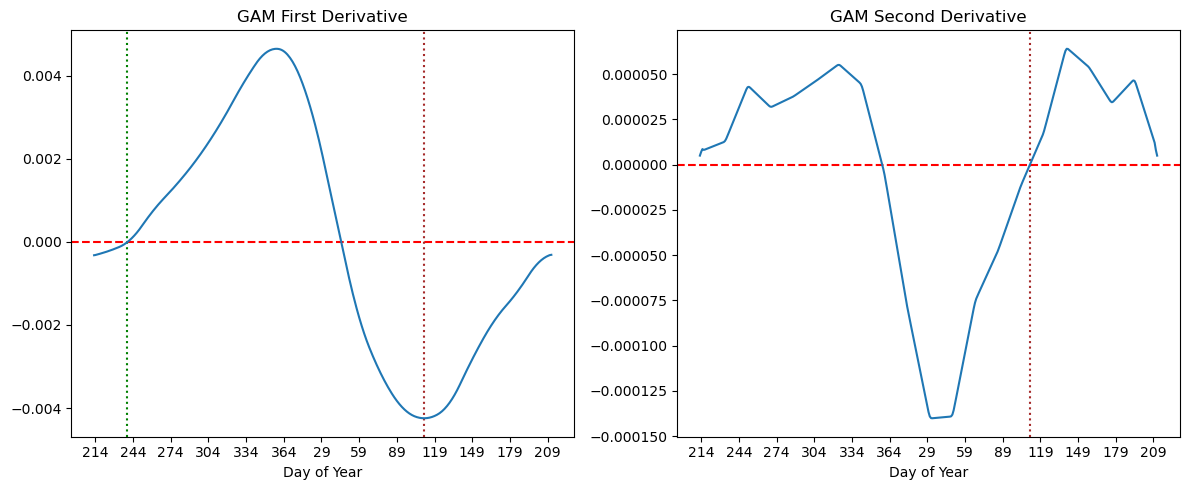

In [408]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
#plt.figure(figsize=(10,5))
ax[0].set_title("GAM First Derivative")
ax[0].axhline(y=0, color='red', linestyle='--')
ax[0].set_xticks(x_ticks, labels=x_labels)
ax[0].set_xlabel("Day of Year")
ax[0].axvline(x=shifted_growining_season, color='green', linestyle=':', label="Start of Season")
ax[0].axvline(x=shifted_max_senescence, color='brown', linestyle=':', label="Max Senescence")
ax[0].plot(dy_dx)

ax[1].set_title("GAM Second Derivative")
ax[1].axhline(y=0, color='red', linestyle='--')
ax[1].set_xticks(x_ticks, labels=x_labels)
ax[1].set_xlabel("Day of Year")
ax[1].axvline(x=shifted_max_senescence, color='brown', linestyle=':', label="Max Senescence")
ax[1].plot(d2y_dx2)

plt.tight_layout()
plt.show()

The `LinearGAM` has a first derivative representing the change in NDVI per individual day, while the second derivative describes the relative acceleration/deceleration of greening within the crops.


- The **Start of Season** phase starts at $\frac{dy}{dx}>0$, i.e. the moment the maize emerges. This can be seen at around DOY 239.
- The second derivative has a prominant peak at around DOY 140. This is the point of _maximum deceleration of senescence_ - in other words, the moment where the rapid dying-back or harvesting slows down and goes dormant and crops are not greening at all ($\frac{dy}{dx}<0$)


### Cummulative GDD

We now start the process for the feature `Cumulative_GDD`. This feature is zero throughout the whole season *until* the moment growing season starts. In the absense of extreme environmental anomalies, the maturity of the crops can in essence be seen as a function of daily temperature. The `Cumulative_GDD` will therefore give us a good indication of the current growing stage of the crop. Note that this features resets to 0 each year when the growing season has ended.

How do we define when the cumulation starts and ends for each year? We use the **zero-crossing** and point of dormancy we found using our cyclic GAM. 

$$
\begin{align} 
\text{DOY of season start: }&DOY_{S_i} = 239 \\
\text{DOY of season end (bare soil): }&DOY_{S_f} \approx 140
\end{align}
$$

We will be using the `non_spectral_df` dataset for this, since GDD does not need NDVI to be calculated, so we can use all daily observations from beginning 2018 to end 2025. 


In [411]:
growing_season = 239
season_end = 140

# Change the global shift period
shift = growing_season

In [414]:
gdd_df = non_spectral_df.copy()
gdd_df["doy"] = gdd_df["Timestamp"].dt.dayofyear
gdd_df["shifted_doy"] = gdd_df["doy"].apply(shift_doy)
gdd_df["year"] = gdd_df["Timestamp"].dt.year
years = np.unique(gdd_df["year"])
gdd_df.head()

,Timestamp,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation,GDD,doy,shifted_doy,year
0,2018-01-01,0.371225,0.394800,0.302474,0.270380,294.466628,294.026363,293.144239,290.955942,293.314439,284.922923,301.389491,3.288490e+07,0.000000,10.006207,1,128,2018
1,2018-01-02,0.347555,0.379907,0.302010,0.270373,293.848773,293.884632,293.162249,290.987094,289.883795,285.298415,295.811490,3.127135e+07,0.000000,7.404952,2,129,2018
2,2018-01-03,0.330737,0.367946,0.301465,0.270366,293.911082,293.727159,293.150462,291.017846,290.475579,283.975136,296.656369,2.872766e+07,0.000000,7.165753,3,130,2018
3,2018-01-04,0.315402,0.356416,0.300741,0.270358,294.503247,293.925443,293.141661,291.047929,291.254956,283.692780,298.823837,3.154392e+07,2.618651,8.108309,4,131,2018
4,2018-01-05,0.302094,0.344448,0.299777,0.270349,295.542367,294.539959,293.180125,291.077664,293.653434,284.633106,302.508414,3.183471e+07,1.835338,10.420760,5,132,2018


Our first important step for this process is to account for the fact that the full growth season does not take place within a single calendar year, so `.groupby()` breaks a season in half. This issue extends to another issue in that we have multiple years' worth of data. Without a "pointer" to a specific growth season/year, we will just be summing all the multi-year GDD's corresponding to some $DOY$. 
Therefore we define a new feature called `Ag_year`, i.e. the agricultural year under consideration spanning from the start of the growing season until after the harvest. 

To see how `Ag_year` works, consider some arbitrary DOY $d_t$ with corresponding year $y_t$. 
$$\therefore \text{AG-year}(d_t, y_t) = \begin{cases} y_t & \text{if } d_t \ge DOY_{S_i} \\ y_t-1 & \text{otherwise} \end{cases}$$

# Feature Engineering

## Volumetric soil water layers and soil temperature layers 

Maize crops are deep-rooted with the following cycles:
- During its vegetative stages (VE-V3), seminal roots grow mostly within 0-20cm.
- The rapid vegetative growth period (V4-V10) is when roots commonly penetrate to 40-80cm.
- Pre-tassling to flowering period (V10-VT) sees active roots extending to 1.0-1.5m
- At full maturity, the maximum root depth reaches ~1.5-2.0m (sometimes deeper).

The bulk of functional roots is not at maximum depth. It typically remains in the upper profile, i.e. 0-30cm, with depths exceeding 120cm important during _drought_ periods. 


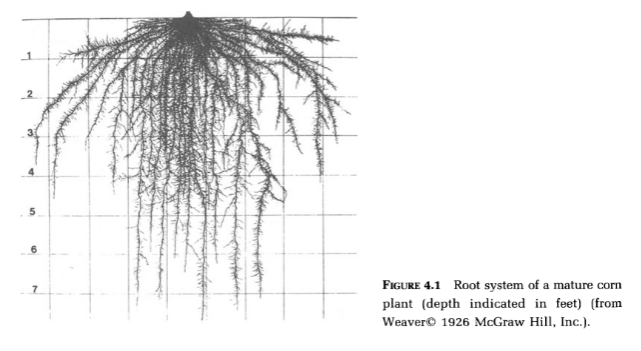

https://link.springer.com/chapter/10.1007/978-1-4612-2694-9_4 

The ERA5 dataset provides us with 4 layers of soil temperature and volumetric water layers. 


| Band Name                     | Unit            | Description                                                                                                                                                                                                                                                                                                                |   |
|-------------------------------|-----------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|---|
| soil_temperature_level_1      | K               | Temperature of the soil in layer 1 (0 - 7 cm) of the ECMWF Integrated Forecasting System. The surface is at 0 cm. Soil temperature is set at the middle of each layer, and heat transfer is calculated at the interfaces between them. It is assumed that there is no heat transfer out of the bottom of the lowest layer. |   |
| soil_temperature_level_2      | K               | Temperature of the soil in layer 2 (7-28 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                   |   |
| soil_temperature_level_3      | K               | Temperature of the soil in layer 3 (28-100 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                 |   |
| soil_temperature_level_4      | K               | Temperature of the soil in layer 4 (100-289 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                |   |
| volumetric_soil_water_layer_1 | Volume fraction | Volume of water in soil layer 1 (0 - 7 cm) of the ECMWF Integrated Forecasting System. The surface is at 0 cm. The volumetric soil water is associated with the soil texture (or classification), soil depth, and the underlying groundwater level.                                                                        |   |
| volumetric_soil_water_layer_2 | Volume fraction | Volume of water in soil layer 2 (7 -28 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                     |   |
| volumetric_soil_water_layer_3 | Volume fraction | Volume of water in soil layer 3 (28-100 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                    |   |
| volumetric_soil_water_layer_4 | Volume fraction | Volume of water in soil layer 4 (100-289 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                   |   |





Naturally considering these as predictors for any model introduces a significant amount of multicolinearity. One might think that dimensionality reduction would be a valid approach to address this issue, however there is a caveat - a climate shock will not have a noteworthy influence on the deep layers in a similar way that it may have on the volatile shallow levels. We must avoid a situation where these deeper layers are used mathematical anchors such  that a large change in the shallow layers will be circumvented by an insignifcant change in the deeper layers. 


### Volumetric Soil Water Layer

As stated above, the deeper layers are typically not the most important when it comes to the maize's health. This leads us to two potential paths forward:

1. **Root weighted averaging depending on growth stage**: A maize plant in its early growth stages will not have a penetrating root system at 180cm, but a mature maize plant will. We therefore introduce as features **root-zone soil moisture** ($SM_{e}$, $SM_{m}$) for both the *early* and *mature* stages of the crop:
        - $SM_{m} = $ 0-30cm has 40-50% of total water uptake, 30-100cm has 40-45% and 100-289cm has ~20%. 
        - $SM_{e} = $ 0-30cm 70-80% and 20-30% to 30-100cm

2. _Truncated_ or _Split-depth_ **Principal Component Analysis**: Instead of running one global PCA on all 4 layers, we split layers 1 and 2 from 3 and 4, and project each of these down to their first direction of maximum variance.



### Soil Temperature Layers

Soil temperatures at layers 1 and 2 are highly volatile, with swings typically mirroring the current surface weather exactly. The deeper soil temperatures are hardly effected by the diurnal temperature, meaning that the daily weather is entirely erased by the time we reach 100-289cm. Aditionally, depending on the row spacing, the maize canopy closes typically closes between the V10 and V14 vegatitve stages, which significantly reduces the diurnal fluctation at shallow levels. We will therefore follow this approach for the soil temperature:
- Drop layers 3 and 4 entirely
- Shift to air temperature and solar radiation once we reach V10-V14 vegatative stages.


In [88]:
# Define constants

VOL_SOIL = "volumetric_soil_water_layer"
SOIL_TEMP =  "soil_temperature_level"
SUB_STRINGS = {VOL_SOIL:4, SOIL_TEMP:2}

dict_items([('volumetric_soil_water_layer', 4), ('soil_temperature_level', 3)])

### Volumetric Soil Water Layers

In [79]:
scaler = StandardScaler()
pca_vw = PCA()
pca_st = PCA()
pcas = [pca_vw, pca_st]

#### Root weighted averaging

### Soil Temperature Layers

In [91]:
# Drop soil temperature layers 3 and 4

mod_non_spectral_df = non_spectral_df.drop(["soil_temperature_level_3", "soil_temperature_level_4"], axis=1).copy()